## Klon repo

In [ ]:
# !rm -rf /content/CENIA_suchanek_kontaminovana_mista_na_Google_colab - na smazání pokud přidát soubory a sem se neprpíšou
!git clone https://github.com/matejpiro/CENIA_suchanek_kontaminovana_mista_na_Google_colab.git

fatal: destination path 'CENIA_suchanek_kontaminovana_mista_na_Google_colab' already exists and is not an empty directory.


## Imports, functions, dictionaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import openpyxl

# for cartograms
import geopandas as gpd
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

### Dictionaries

In [ ]:
cr_inflation = {2013:1.4,
                2014:0.4,
                2015:0.3,
                2016:0.7,
                2017:2.5,
                2018:2.1,
                2019:2.8,
                2020:3.2,
                2021:3.8,
                2022:15.1,
                2023:10.7,
                2024:2.4,
                2025:2.5}

# data from ČSÚ - February 2026

In [ ]:
priority_dict = {
    "ALL": None,

    "A_ALL" : ["A1.0", "A1.1", "A1.2", "A1.3", "A2.0", "A2.1", "A2.2", "A2.3", "A3.1", "A3.2", "A3.3"],

    "A1": ["A1.0", "A1.1", "A1.2", "A1.3"],

    "A2": ["A2.0", "A2.1", "A2.2", "A2.3"],

    "A3": ["A3.1", "A3.2", "A3.3"],

    "P1+P2": [
        "P1.0", "P1.1", "P1.2", "P1.3",
        "P2.0", "P2.1", "P2.2", "P2.3"
    ],

    "P3+P4": [
        "P3.0", "P3.1", "P3.2", "P3.3",
        "P4.0", "P4.1", "P4.2", "P4.3"
    ],

    "N": [
        "N0.0", "N0.1", "N0.2",
        "N1.0", "N1.1", "N1.2",
        "N2.0", "N2.1", "N2.2", "N2.3"
    ]
}

### Functions

In [ ]:
# print locality type info
def print_locality_type_info(selected_code, my_dict, my_counts):
    for key, value in my_dict.items():
        if value == selected_code:
            count = my_counts.get(key, 0)
            print(f"locality type number: {value} / name: {key} / row count: {count}")
            return

    print("Code not found.")

In [ ]:
# print df info:  cols, rows
def print_df_info(my_df):
    num_cols = my_df.shape[1]
    num_rows = my_df.shape[0]
    print("Number of columns:", num_cols)
    print("Number of rows:", num_rows)

### Inflation counter

In [ ]:
# cpi = consumer price index (index spotřebitelských cen)
cpi = pd.Series(cr_inflation).sort_index()
cpi = (1 + cpi/100).cumprod()
my_min = min(cr_inflation) - 1 # základní hodnota o rok nižší než nejnižší rok.
cpi.loc[my_min] = 1
cpi = cpi.sort_index()
cpi_dict = cpi.to_dict()

# inflation counting function
def adjust_by_inflation(starting_value, year_from, year_to):

    if year_from not in cpi_dict  or year_to not in cpi_dict: # if wrong year
            raise ValueError("Year not available in CPI index")

    output_value = starting_value * cpi_dict[year_to] / cpi_dict[year_from] # count
    return output_value

#### Inflation counter - testing

In [ ]:
adjust_by_inflation(100,2021,2025)

133.73551872000002

## SEKM data A)
#### load data, basic DF info

In [ ]:
# load data
My_SEKM_data = "/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab/Export_celý_SEKM_bez_vyloučených_05022026_Matej.xlsx"
mySEKM_DF = pd.read_excel(My_SEKM_data)

In [ ]:
# filtr podle kategorie priority
if SELECTED_PRIORITY_CATEGORY == "ALL":

    mySEKM_filtered_DF = mySEKM_DF.copy()

elif SELECTED_PRIORITY_CATEGORY in priority_dict:

    mySEKM_filtered_DF = mySEKM_DF[
        mySEKM_DF["Kategorie priority"].isin(
            priority_dict[SELECTED_PRIORITY_CATEGORY]
        )
    ].copy()

else:

    raise ValueError(
        f"Neplatná hodnota SELECTED_PRIORITY_CATEGORY: '{SELECTED_PRIORITY_CATEGORY}'. "
        f"Povolené hodnoty jsou: {list(priority_dict.keys())}"
    )

In [ ]:
# basic DF info
print_df_info(mySEKM_filtered_DF)
mySEKM_filtered_DF.head(1)

Number of columns: 45
Number of rows: 10201


,Identifikátor,Identifikátor2,Název lokality,Katastrální území,Kraj,ORP,X,Y,Typ lokality,typ_puvodce_znecisteni,...,"Cíle opatření dle analýzy rizik, priority",Další doporučení dle analýzy rizik,Aktuálnost záznamu,Střety na vlastní lokalitě,Střety v okolí do cca 1 km,Další postup,Charakteristika impaktu kontaminace,Kategorie priority,Stav,Důvod vyloučení
0,91741001,91741001,Boletice - polygon Květušín,Polná na Šumavě,Jihočeský kraj,Český Krumlov,1184488.5,783195.25,střelnice / vojenské výcvikové prostory,armáda,...,2019/05 AR nezpracována_x000D_\nAR nezpracována,NaN,2019-06-10T16:15:48.0Z,"Zemědělská půda,NATURA 2000,VKP, přírodní pamá...","Zdroje pitné vody, jejich vnější ochr. pásmo,Ú...",vzorkováním je potvrzena neexistence nadpozaďo...,není nutný žádný zásah,N0.0,schváleno,NaN


## Detailed cases - data

### Load data

In [ ]:
# LOAD DATA
My_data = "/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab/Data_opzp_6_08_04.xlsx"
my_DF = pd.read_excel(My_data)

my_DF.head(1)

,lokalita,lokalita_dopresni,financovano,ID_SEKM,kategorie_priority,JTSK_X,JTSK_Y,odhad_nakladu_cela_lokalita_(Kc),odhad_nakladu_cela_lokalita_(rok),c_nen_ezak,...,betonovani_zakladu_objem_(m3),betonovani_zakladu_cena_(Kc),cerpani_vody_objem_(m3),cerpani_vody_cena_(Kc),likvidace_vrtu_objem_(m3),likvidace_vrtu_cena_(Kc),manipulace_s_materialem_objem_(m3),manipulace_s_materialem_cena_(Kc),likvidace_odpadu_objem_(m3),likvidace_odpadu_cena_(Kc)
0,SARA LEE,Sara Lee Czech Republic s.r.o. a okolí,MF CR,31285001,A2.1,1042331.612906,737289.727036,52223857.0,2020,N006/20/V00020859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Basic data overview

In [ ]:
print_df_info(my_DF)

Number of columns: 52
Number of rows: 51


In [ ]:
print(my_DF["odhad_nakladu_cela_lokalita_(rok)"].min())
print(my_DF["odhad_nakladu_cela_lokalita_(rok)"].max())

2013
2022


### Inflation
#####  - count inflation, add new column to DF

In [ ]:
# max year in dataframe
year_to = YEAR_TO_COUNT_INFLATION

# name of new column
new_col = f"odhad_nakladu_cela_lokalita_(Kc)_inf_{year_to}"

# map CPI index to each row
cpi_from = my_DF["odhad_nakladu_cela_lokalita_(rok)"].map(cpi_dict) # .map() is way faster than .apply() which is another possible solution

# compute adjusted values
inflated_values = (
    my_DF["odhad_nakladu_cela_lokalita_(Kc)"] *
    cpi_dict[year_to] /
    cpi_from
)

# position where to insert the new column
new_col_position = my_DF.columns.get_loc("odhad_nakladu_cela_lokalita_(Kc)") + 1

# insert column
my_DF.insert(new_col_position, new_col, inflated_values)

In [ ]:
my_DF.head(2)

,lokalita,lokalita_dopresni,financovano,ID_SEKM,kategorie_priority,JTSK_X,JTSK_Y,odhad_nakladu_cela_lokalita_(Kc),odhad_nakladu_cela_lokalita_(Kc)_inf_2025,odhad_nakladu_cela_lokalita_(rok),...,betonovani_zakladu_objem_(m3),betonovani_zakladu_cena_(Kc),cerpani_vody_objem_(m3),cerpani_vody_cena_(Kc),likvidace_vrtu_objem_(m3),likvidace_vrtu_cena_(Kc),manipulace_s_materialem_objem_(m3),manipulace_s_materialem_cena_(Kc),likvidace_odpadu_objem_(m3),likvidace_odpadu_cena_(Kc)
0,SARA LEE,Sara Lee Czech Republic s.r.o. a okolí,MF CR,31285001,A2.1,1042331.612906,737289.727036,52223857.0,7.249584e+07,2020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MORA MORAVIA ŠTERNBERK,MORA MORAVIA s.r.o. Šternberk,MF CR,16352010,A2.1,"1106322,1",542191.56,18269928.0,2.536185e+07,2020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### KC column format

In [ ]:
# format kc columns?
FORMAT_KC_COLUMNS = 0

# dynamicaly created column
my_inflation_col = f"odhad_nakladu_cela_lokalita_(Kc)_inf_{YEAR_TO_COUNT_INFLATION}"

# select columns to output
my_DF_selected_1 = my_DF[["lokalita", "typ_puvodce_znecisteni", "odhad_nakladu_cela_lokalita_(Kc)", "odhad_nakladu_cela_lokalita_(rok)",my_inflation_col]]

# compute diff in CZK and diff in %
my_DF_selected_1["cena_diff_(Kc)"] = my_DF_selected_1[my_inflation_col] - my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]
my_DF_selected_1["cena_diff_(%)"] = (((my_DF_selected_1[my_inflation_col] / my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]) * 100) - 100).round(1)

# format certain columns nicely - string!
if FORMAT_KC_COLUMNS == 1:

    cols_to_format = [
        "odhad_nakladu_cela_lokalita_(Kc)",
        my_inflation_col,
        "cena_diff_(Kc)"]

    for col in cols_to_format:
        my_DF_selected_1[col] = my_DF_selected_1[col].map("{:,.2f}".format)

# display
my_DF_selected_1.head(2)

/tmp/ipykernel_2571/917570404.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_DF_selected_1["cena_diff_(Kc)"] = my_DF_selected_1[my_inflation_col] - my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]
/tmp/ipykernel_2571/917570404.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_DF_selected_1["cena_diff_(%)"] = (((my_DF_selected_1[my_inflation_col] / my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]) * 100) - 100).round(1)


,lokalita,typ_puvodce_znecisteni,odhad_nakladu_cela_lokalita_(Kc),odhad_nakladu_cela_lokalita_(rok),odhad_nakladu_cela_lokalita_(Kc)_inf_2025,cena_diff_(Kc),cena_diff_(%)
0,SARA LEE,potravinářství,52223857.0,2020,7.249584e+07,2.027198e+07,38.8
1,MORA MORAVIA ŠTERNBERK,strojírenství,18269928.0,2020,2.536185e+07,7.091924e+06,38.8


#### Save excel

In [ ]:
if SAVE_EXCEL_INFLATION == 1:

    my_DF_selected_1.to_excel(
        "C:/Users/matej.piro/Desktop/my_DF_selected_1.xlsx",
        index=False
    )
    print("Excel created")

else:
    print("No excel for you now")

No excel for you now


### Compute MEDIAN, AVG per selected categories
##### žádná váha dle rozlohy

In [ ]:
# přidá kategorii "ostatní" kam shrne vše mimo selected_types_puvodce_znecisteni_types
def count_mean_median_for_sel_types(df, selected_types):
    '''group by typ_puvodce_znecisteni, count mean, median,
    add nick column, returns df'''

    # původní vybrané kategorie
    result_df = df[
        df["typ_puvodce_znecisteni"].isin(selected_types)
    ].groupby(
        "typ_puvodce_znecisteni"
    )[
        "odhad_nakladu_cela_lokalita_(Kc)_inf_2025"
    ].agg(["count", "mean", "median"])

    # souhrnná kategorie "ostatní"
    ostatni_df = df[
        ~df["typ_puvodce_znecisteni"].isin(selected_types)
    ][
        "odhad_nakladu_cela_lokalita_(Kc)_inf_2025"
    ].agg(["count", "mean", "median"])

    result_df.loc["ostatní"] = ostatni_df

    # add nick column
    result_df["nick"] = result_df.index.str[:4]
    result_df = result_df[["nick", "count", "mean", "median"]]

    return result_df

In [ ]:
# list of selected categories
selected_types_puvodce_znecisteni_types = ["strojírenství",
                                         "plynárenství",
                                         "chemický průmysl (léčiva, gumárenství, plasty, umělá vlákna...)",
                                         "doprava a distribuce (produktovody, distribuční sklady)",
                                         "hutnictví a slévárenství",
                                         "ostatní"
                                        ]

In [ ]:
# call function, visualise
detailed_cases_result_df = count_mean_median_for_sel_types(my_DF_selected_1,selected_types_puvodce_znecisteni_types)

detailed_cases_result_df.head(6)

,nick,count,mean,median
typ_puvodce_znecisteni,,,,
"chemický průmysl (léčiva, gumárenství, plasty, umělá vlákna...)",chem,4.0,5.557351e+08,4.550693e+08
"doprava a distribuce (produktovody, distribuční sklady)",dopr,5.0,6.982800e+07,7.256572e+07
hutnictví a slévárenství,hutn,4.0,2.062015e+08,1.356710e+08
plynárenství,plyn,3.0,3.846851e+07,1.884620e+07
strojírenství,stro,15.0,1.441613e+08,2.793563e+07
ostatní,osta,20.0,4.900273e+07,2.488748e+07


## SEKM data B)

#### SEKM DF info

In [ ]:
print_df_info(mySEKM_filtered_DF)
mySEKM_filtered_DF.head(1)

Number of columns: 45
Number of rows: 10201


,Identifikátor,Identifikátor2,Název lokality,Katastrální území,Kraj,ORP,X,Y,Typ lokality,typ_puvodce_znecisteni,...,"Cíle opatření dle analýzy rizik, priority",Další doporučení dle analýzy rizik,Aktuálnost záznamu,Střety na vlastní lokalitě,Střety v okolí do cca 1 km,Další postup,Charakteristika impaktu kontaminace,Kategorie priority,Stav,Důvod vyloučení
0,91741001,91741001,Boletice - polygon Květušín,Polná na Šumavě,Jihočeský kraj,Český Krumlov,1184488.5,783195.25,střelnice / vojenské výcvikové prostory,armáda,...,2019/05 AR nezpracována_x000D_\nAR nezpracována,NaN,2019-06-10T16:15:48.0Z,"Zemědělská půda,NATURA 2000,VKP, přírodní pamá...","Zdroje pitné vody, jejich vnější ochr. pásmo,Ú...",vzorkováním je potvrzena neexistence nadpozaďo...,není nutný žádný zásah,N0.0,schváleno,NaN


##### SEKM DF typ_puvodce_znecisteni info

In [ ]:
# COUNT BY: typ_puvodce_znecisteni

# map a number to each typ_puvodce_znecisteni type
categories = sorted(
    mySEKM_filtered_DF["typ_puvodce_znecisteni"].dropna().unique()
)

# dictionary
mapping_dict_SEKM = {cat: i + 1 for i, cat in enumerate(categories)}

# new column "typ_puvodce_znecisteni_code" into DF on second index
mySEKM_filtered_DF.insert(
    1,
    "typ_typ_puvodce_znecisteni_code",
    mySEKM_filtered_DF["typ_puvodce_znecisteni"].map(mapping_dict_SEKM)
)

# get counts of each typ_puvodce_znecisteni type
counts = mySEKM_filtered_DF["typ_puvodce_znecisteni"].value_counts()

# print dictionary with counts
for key, value in mapping_dict_SEKM.items():
    count = counts.get(key, 0)
    print(f"{value} - {key} (count: {count})")

1 - armáda (count: 276)
2 - chemický průmysl (léčiva, gumárenství, plasty, umělá vlákna...) (count: 194)
3 - doprava a distribuce (produktovody, distribuční sklady) (count: 233)
4 - dřevozpracující a papírenský průmysl (count: 95)
5 - elektrotechnika (count: 60)
6 - hornictví (count: 186)
7 - hutnictví a slévárenství (count: 116)
8 - jiné (count: 1165)
9 - koksárenství (count: 14)
10 - komunální odpady (count: 4363)
11 - kožedělný průmysl (count: 28)
12 - nespecifikováno (count: 4)
13 - neznámo (count: 3)
14 - plynárenství (count: 115)
15 - potravinářství (count: 87)
16 - sběrné suroviny, autovrakoviště (count: 364)
17 - sklářství, keramika, cihelny, zpracování minerálních nekovových hmot (count: 204)
18 - strojírenství (count: 566)
19 - textilní průmysl (count: 87)
20 - výroba a distribuce elektrické energie (count: 574)
21 - zemědělství, lesnictví (count: 869)
22 - zpracování ropy (count: 101)
23 - čerpací stanice PHM (count: 497)


### test - Try filtering

In [ ]:
# FILTER:
## typ_puvodce_znecisteni = strojírenství
## kategorie priority začíná na P
## Kraj = Jihomoravský
# my_selected_SEKM_df = mySEKM_filtered_DF[
#     (mySEKM_filtered_DF["typ_puvodce_znecisteni"] == "strojírenství") &
#     (mySEKM_filtered_DF["Kategorie priority"].str.startswith("P", na=False)) &
#     (mySEKM_filtered_DF["Kraj"] == "Jihomoravský kraj")
# ]

my_selected_SEKM_df = mySEKM_filtered_DF[
    (mySEKM_filtered_DF["typ_puvodce_znecisteni"].isin(selected_types_puvodce_znecisteni_types)) &
    (mySEKM_filtered_DF["Kraj"] == "Ústecký kraj")
]

print_df_info(my_selected_SEKM_df)

Number of columns: 46
Number of rows: 84


In [ ]:
my_selected_SEKM_df.head(1)

,Identifikátor,typ_typ_puvodce_znecisteni_code,Identifikátor2,Název lokality,Katastrální území,Kraj,ORP,X,Y,Typ lokality,...,"Cíle opatření dle analýzy rizik, priority",Další doporučení dle analýzy rizik,Aktuálnost záznamu,Střety na vlastní lokalitě,Střety v okolí do cca 1 km,Další postup,Charakteristika impaktu kontaminace,Kategorie priority,Stav,Důvod vyloučení
5046,8770001,2,8770001,Lovochemie a.s.,Lovosice,Ústecký kraj,Lovosice,992837.810807,760323.068993,výroba/skladování/manipulace s nebezpečnými lá...,...,2020/11 Cíle nápravných opatření nejsou třeba,NaN,2020-11-26T17:26:12.297Z,Území CHOPAV,"Zemědělská půda,Území CHKO",stávající kontaminace by znamenala vznik neakc...,nutnost institucionální kontroly způsobu využí...,P1.0,schváleno,NaN


In [ ]:
my_selected_SEKM_df_short = my_selected_SEKM_df[["Název lokality", "Kraj", "ORP", "typ_puvodce_znecisteni", "Plocha m2", "Kategorie priority"]]
my_selected_SEKM_df_short.head(1)

,Název lokality,Kraj,ORP,typ_puvodce_znecisteni,Plocha m2,Kategorie priority
5046,Lovochemie a.s.,Ústecký kraj,Lovosice,"chemický průmysl (léčiva, gumárenství, plasty,...",NaN,P1.0


### Modifying mySEKM_filtered_DF into mySEKM_modified_DF
##### "typ_puvodce_znecisteni" vše krom pěti vybraných (z "selected_types_puvodce_znecisteni_types") do "ostatní"

In [ ]:
mySEKM_modified_DF = mySEKM_filtered_DF.copy()

mySEKM_modified_DF.loc[
    ~mySEKM_modified_DF["typ_puvodce_znecisteni"].isin(selected_types_puvodce_znecisteni_types),
    "typ_puvodce_znecisteni"
] = "ostatní"

In [ ]:
# zobraz
mySEKM_modified_DF["typ_puvodce_znecisteni"].value_counts()

,count
typ_puvodce_znecisteni,
ostatní,8977
strojírenství,566
"doprava a distribuce (produktovody, distribuční sklady)",233
"chemický průmysl (léčiva, gumárenství, plasty, umělá vlákna...)",194
hutnictví a slévárenství,116
plynárenství,115


### Add columns with computed values to SEKM df

In [ ]:
# 24.6. SMAŽ
detailed_cases_result_df.head(8)

,nick,count,mean,median
typ_puvodce_znecisteni,,,,
"chemický průmysl (léčiva, gumárenství, plasty, umělá vlákna...)",chem,4.0,5.557351e+08,4.550693e+08
"doprava a distribuce (produktovody, distribuční sklady)",dopr,5.0,6.982800e+07,7.256572e+07
hutnictví a slévárenství,hutn,4.0,2.062015e+08,1.356710e+08
plynárenství,plyn,3.0,3.846851e+07,1.884620e+07
strojírenství,stro,15.0,1.441613e+08,2.793563e+07
ostatní,osta,20.0,4.900273e+07,2.488748e+07


In [ ]:
# adding columns
mySEKM_modified_DF["pred_mean_price"] = mySEKM_modified_DF["typ_puvodce_znecisteni"].map(detailed_cases_result_df["mean"])
mySEKM_modified_DF["pred_median_price"] = mySEKM_modified_DF["typ_puvodce_znecisteni"].map(detailed_cases_result_df["median"])

In [ ]:
# how many rows were afected
mask = mySEKM_modified_DF["typ_puvodce_znecisteni"].isin(selected_types_puvodce_znecisteni_types)

count_match = mask.sum()
count_other = (~mask).sum()

print("Našich pět typů původce znečištění reprezentuje:", count_match, "řádků.")
print("Nepoužíváme:", count_other, "řádků.")

Našich pět typů původce znečištění reprezentuje: 10201 řádků.
Nepoužíváme: 0 řádků.


### Count and output per "Kraje"

In [ ]:
# filter by selected_types_puvodce_znecisteni_types
selected_typ_puvodce_znecisteni_df = mySEKM_modified_DF[
    mySEKM_modified_DF["typ_puvodce_znecisteni"].isin(selected_types_puvodce_znecisteni_types)
]

##### by Kraj and typ_puvodce_znecisteni

In [ ]:
# group by Kraj and typ_puvodce_znecisteni
Kraje_a_typy_puvodce_price_pred_df = selected_typ_puvodce_znecisteni_df.groupby(
    ["Kraj", "typ_puvodce_znecisteni"]
)[["pred_mean_price", "pred_median_price"]].sum().reset_index()

In [ ]:
# prices to mld CZK
Kraje_a_typy_puvodce_price_pred_df["pred_mean_price(mld_CZK)"] = Kraje_a_typy_puvodce_price_pred_df["pred_mean_price"] / 1000000000
Kraje_a_typy_puvodce_price_pred_df["pred_median_price(mld_CZK)"] = Kraje_a_typy_puvodce_price_pred_df["pred_median_price"] / 1000000000

# drop columns
Kraje_a_typy_puvodce_price_pred_df = Kraje_a_typy_puvodce_price_pred_df.drop(["pred_mean_price","pred_median_price"], axis=1)

In [ ]:
Kraje_a_typy_puvodce_price_pred_df.head(1)

,Kraj,typ_puvodce_znecisteni,pred_mean_price(mld_CZK),pred_median_price(mld_CZK)
0,Hlavní město Praha,"chemický průmysl (léčiva, gumárenství, plasty,...",7.780292,6.370971


##### by ORP and typ_puvodce_znecisteni

In [ ]:
# group by ORP and typ_puvodce_znecisteni
ORP_a_typy_puvodce_price_pred_df = selected_typ_puvodce_znecisteni_df.groupby(
    ["ORP", "typ_puvodce_znecisteni"]
)[["pred_mean_price", "pred_median_price"]].sum().reset_index()

In [ ]:
# prices to mld CZK
ORP_a_typy_puvodce_price_pred_df["pred_mean_price(mld_CZK)"] = ORP_a_typy_puvodce_price_pred_df["pred_mean_price"] / 1000000000
ORP_a_typy_puvodce_price_pred_df["pred_median_price(mld_CZK)"] = ORP_a_typy_puvodce_price_pred_df["pred_median_price"] / 1000000000

# drop columns
ORP_a_typy_puvodce_price_pred_df = ORP_a_typy_puvodce_price_pred_df.drop(["pred_mean_price","pred_median_price"], axis=1)

##### ORP Filtr by only ONE Kraj

In [ ]:
# FILTRUJ JEDEN KRAJ
# ORP BY KRAJ - output in list

def ORP_list_by_kraj(df, kraj):
    orp_by_kraj_list = df.loc[
    df["Kraj"] == kraj,
    "ORP"].unique().tolist()

    if not orp_by_kraj_list:
        raise ValueError(f"Kraj '{kraj}' neexistuje.")

    return orp_by_kraj_list

In [ ]:
# ORP Ústecký kraj
ORP_ustecky = ORP_list_by_kraj(mySEKM_modified_DF,"Ústecký kraj")

In [ ]:
ORP_jeden_kraj_a_typy_puvodce_price_pred_df = ORP_a_typy_puvodce_price_pred_df[
    ORP_a_typy_puvodce_price_pred_df["ORP"].isin(ORP_ustecky)
]

In [ ]:
print_df_info(ORP_jeden_kraj_a_typy_puvodce_price_pred_df)
ORP_jeden_kraj_a_typy_puvodce_price_pred_df.head()

Number of columns: 4
Number of rows: 55


,ORP,typ_puvodce_znecisteni,pred_mean_price(mld_CZK),pred_median_price(mld_CZK)
55,Bílina,ostatní,0.833046,0.423087
67,Chomutov,"doprava a distribuce (produktovody, distribučn...",0.069828,0.072566
68,Chomutov,hutnictví a slévárenství,0.618605,0.407013
69,Chomutov,ostatní,1.568087,0.796399
70,Chomutov,plynárenství,0.115406,0.056539


##### by Kraj

In [ ]:
# group by Kraj
Kraje_price_pred_df = selected_typ_puvodce_znecisteni_df.groupby(
    ["Kraj"]
)[["pred_mean_price", "pred_median_price"]].sum().reset_index()

In [ ]:
# prices to mld CZK
Kraje_price_pred_df["pred_mean_price(mld_CZK)"] = Kraje_price_pred_df["pred_mean_price"] / 1000000000
Kraje_price_pred_df["pred_median_price(mld_CZK)"] = Kraje_price_pred_df["pred_median_price"] / 1000000000

# drop columns
Kraje_price_pred_df = Kraje_price_pred_df.drop(["pred_mean_price","pred_median_price"], axis=1)

In [ ]:
Kraje_price_pred_df.head()

,Kraj,pred_mean_price(mld_CZK),pred_median_price(mld_CZK)
0,Hlavní město Praha,42.328610,23.217065
1,Jihomoravský kraj,54.345965,30.565266
2,Jihočeský kraj,38.974395,20.059120
3,Karlovarský kraj,15.960528,8.240038
4,Kraj Vysočina,37.271736,19.097181


##### by ORP

In [ ]:
# group by Kraj
ORP_price_pred_df = selected_typ_puvodce_znecisteni_df.groupby(
    ["ORP"]
)[["pred_mean_price", "pred_median_price"]].sum().reset_index()

In [ ]:
# prices to mld CZK
ORP_price_pred_df["pred_mean_price(mld_CZK)"] = ORP_price_pred_df["pred_mean_price"] / 1000000000
ORP_price_pred_df["pred_median_price(mld_CZK)"] = ORP_price_pred_df["pred_median_price"] / 1000000000

# drop columns
ORP_price_pred_df = ORP_price_pred_df.drop(["pred_mean_price","pred_median_price"], axis=1)

##### Excel output: Kraje_a_typy_puvodce_price_pred_df, Kraje_price_pred_df

In [ ]:
# output to excel on desktop
KRAJE_EXCEL_OUTPUT = 0

if KRAJE_EXCEL_OUTPUT == 1:

    Kraje_a_typy_puvodce_price_pred_df.to_excel(
        r"C:/Users/matej.piro/Desktop/output_Kraje_a_typy_puvodce_price_pred_df.xlsx",
        index=False
    )

    Kraje_price_pred_df.to_excel(
        r"C:/Users/matej.piro/Desktop/output_Kraje_price_pred_df.xlsx",
        index=False
    )

## Cartograms

#### Prapare data

In [ ]:
# kraje id dict
kraj_map = {
    "CZ010": "Hlavní město Praha",
    "CZ020": "Středočeský kraj",
    "CZ031": "Jihočeský kraj",
    "CZ032": "Plzeňský kraj",
    "CZ041": "Karlovarský kraj",
    "CZ042": "Ústecký kraj",
    "CZ051": "Liberecký kraj",
    "CZ052": "Královéhradecký kraj",
    "CZ053": "Pardubický kraj",
    "CZ063": "Kraj Vysočina",
    "CZ064": "Jihomoravský kraj",
    "CZ071": "Olomoucký kraj",
    "CZ072": "Zlínský kraj",
    "CZ080": "Moravskoslezský kraj"
}

In [ ]:
my_geojson_kraje = r"/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab/kraje.json"
my_geojson_orp = r"/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab/orp.geojson"

my_geo_kraje_df = gpd.read_file(my_geojson_kraje)
my_geo_orp_df = gpd.read_file(my_geojson_orp)

In [ ]:
# Changes in df

# strip id column
my_geo_kraje_df["id"] = my_geo_kraje_df["id"].str[:-7]

# map kraje dict
my_geo_kraje_df["kraj"] = my_geo_kraje_df["id"].map(kraj_map)

In [ ]:
print_df_info(my_geo_kraje_df)
my_geo_kraje_df.head(1)

Number of columns: 3
Number of rows: 14


,id,geometry,kraj
0,CZ010,"POLYGON ((14.52826 49.99984, 14.52839 49.99991...",Hlavní město Praha


#### Cartogram settings

In [ ]:
my_geo_kraje_df.head(2)

,id,geometry,kraj
0,CZ010,"POLYGON ((14.52826 49.99984, 14.52839 49.99991...",Hlavní město Praha
1,CZ020,"POLYGON ((15.4973 49.97005, 15.4971 49.97014, ...",Středočeský kraj


##### Function

In [ ]:
# DEF FUNCTION

# stats_quantity je buď "medián" nebo "průměr"
# scenario_percent_change je parametr procentuální změny vstupních dat. Zadáváme v %

def create_kraje_cartogram(geo_kraje_df,color_list,stats_quantity,text_1_dict,text_2_dict,text_3_dict,scenario_percent_change=100, watermark=False, watermark_text="TEST", save=False):
    # checks
    if stats_quantity not in ["medián", "median", "MEDIÁN", "MEDIAN", "průměr", "prumer", "PRŮMĚR", "PRUMER"]:
        raise ValueError("stats_quantity must be 'medián' or 'průměr'")

    geo_kraje_df = geo_kraje_df.copy()

    # přepočet hodnot podle zadaného procenta
    scale_factor = scenario_percent_change / 100

    geo_kraje_df["cena_upravena"] = (geo_kraje_df["cena (mld CZK)"] * scale_factor)

    num_bins = 5
    my_colors = color_list

    # --- BINS ---
    bins = np.linspace(
        geo_kraje_df["cena_upravena"].min(),
        geo_kraje_df["cena_upravena"].max(),
        num_bins + 1
    )

    # --- COLORMAP + NORM ---
    cmap = ListedColormap(my_colors)
    norm = BoundaryNorm(bins, len(my_colors))

    # --- PLOT ---
    fig, ax = plt.subplots(figsize=(10, 10))

    praha = geo_kraje_df[geo_kraje_df["id"] == "CZ010"]
    zbytek = geo_kraje_df[geo_kraje_df["id"] != "CZ010"]

    # nejdřív vykresli velké celky
    zbytek.plot(
        column="cena_upravena",
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.8,
        ax=ax
    )

    # nakonec vykresli Prahu
    praha.plot(
        column="cena_upravena",
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=1.2,
        ax=ax
    )

    # --- LEGEND ---
    legend_patches = [
        Patch(
            facecolor=my_colors[i],
            edgecolor="black",
            label=f"{bins[i]:.1f}–{bins[i+1]:.1f}"
        )
        for i in range(num_bins)
    ]

    ax.legend(
        handles=legend_patches,
        title="mld CZK",
        loc="upper right",
        frameon=False
    )

    # text 1
    ax.text(**text_1_dict)

    # text 2
    ax.text(**text_2_dict)

    # text 3
    ax.text(**text_3_dict)

    plt.title(
        f"Distribuce ekologické zátěže dle databáze SEKM po krajích ČR, 2026.\n"
        f"Vypočtená dle {stats_quantity}ů cen* známých likvidací zátěže z předešlých let.\n"
        f"Kategorie priority = {SELECTED_PRIORITY_CATEGORY}\n"
        f"Scénář = {scenario_percent_change}%"
    )

    # vodoznak
    if watermark:
        fig.text(
            0.5, 0.5,
            watermark_text,
            fontsize=90,
            color="gray",
            alpha=0.32,
            ha="center",
            va="center",
            rotation=30,
            weight="bold"
        )

    # save
    if save:  # means "if save = True"
        safe_stats = (
            stats_quantity
            .replace("á", "a")
            .replace("ů", "u")
        )

        path = (
            fr"C:/Users/matej.piro/Desktop/"
            fr"cartogram_{safe_stats}_{SELECTED_PRIORITY_CATEGORY}_{scenario_percent_change}pct.png"
        )

        plt.savefig(path, dpi=300, bbox_inches="tight")

    plt.show()

##### Cartogram texts, colors - dict definition

In [ ]:
# text dicts
text_1_dict = {
    "x": 17.2,
    "y": 48.5,
    "s": "Data: CENIA, SEKM \nVyhotovil: Matěj Píro, 2026",
    "fontsize": 10,
    "color": "black"
}

text_2_dict = {
    "x": 11.9,
    "y": 48.5,
    "s": "Tito \npůvodci \nznečištění:\n\n" \
    "- plynárenství,\n" \
    "- strojírenství,\n" \
    "- chemický průmysl,\n" \
    "- doprava a distribuce,\n" \
    "- hutnictví a slévárenství\n\n"
    " započteni přímo.\n"
    " Další započítáni v kategorii \"ostatní\".",

    "fontsize": 9,
    "color": "black"
}

text_3_dict = {
    "x": 14.5,
    "y": 48.5,
    "s": "*Ceny přepočteny na úroveň roku 2025.",
    "fontsize": 9,
    "color": "black"
}

# color list
my_colors_list = [
    "moccasin",
    "gold",
    "orange",
    "orangered",
    "maroon"
]

#### Create Cartograms - Kraje

In [ ]:
# map
kraj_price_map = dict(zip(
    Kraje_price_pred_df["Kraj"],
    Kraje_price_pred_df["pred_median_price(mld_CZK)"]
))

my_geo_kraje_df["cena (mld CZK)"] = my_geo_kraje_df["kraj"].map(kraj_price_map)

## Output

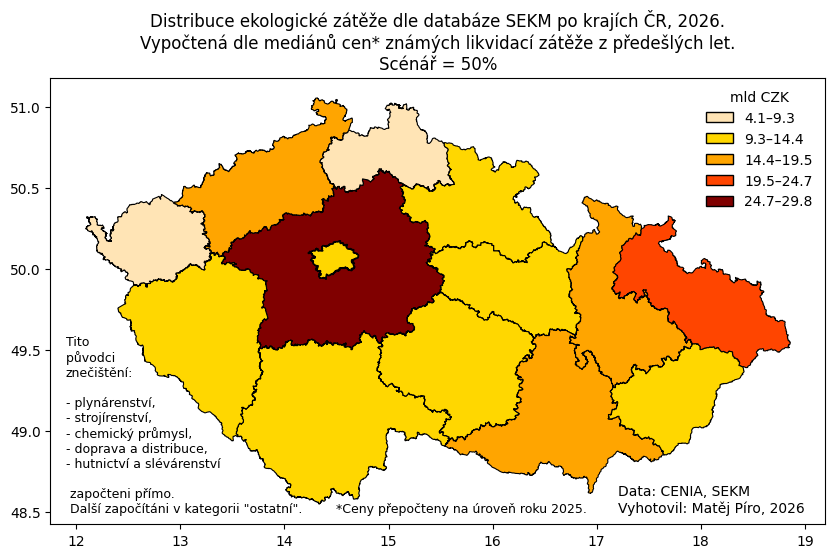

In [ ]:
if globals().get("RUN_CARTOGRAM", True):
    create_kraje_cartogram(
        my_geo_kraje_df,
        my_colors_list,
        SELECTED_STAT_METHOD,
        text_1_dict,
        text_2_dict,
        text_3_dict,
        MY_PERCENTAGE_SCENARIO,
        save=SAVE_CARTOGRAMS
    )

In [ ]:
print(
    pd.DataFrame({
        "kraj": my_geo_kraje_df["kraj"],
        "cena (mld CZK)": my_geo_kraje_df["cena (mld CZK)"] * MY_PERCENTAGE_SCENARIO / 100 # započten % scénář
    })
)

                    kraj  cena (mld CZK)
0     Hlavní město Praha       11.608533
1       Středočeský kraj       29.824799
2         Jihočeský kraj       10.029560
3          Plzeňský kraj       13.815812
4       Karlovarský kraj        4.120019
5           Ústecký kraj       15.604331
6         Liberecký kraj        7.296368
7   Královéhradecký kraj        9.287005
8        Pardubický kraj       10.367189
9          Kraj Vysočina        9.548590
10     Jihomoravský kraj       15.282633
11        Olomoucký kraj       15.022821
12  Moravskoslezský kraj       19.612921
13          Zlínský kraj        9.740840
